In [3]:
%load_ext autoreload
%autoreload 2

import glob
import os
import pickle

import numpy as np
import pytest
import sys

sys.path.insert(0,'uqmodels')
import uqmodels.visualization.visualization as visu
from uqmodels.evaluation.evaluation import evaluate
from uqmodels.evaluation.metrics import Generic_metric, UQ_average_coverage, rmse
from uqmodels.preprocessing.Custom_Preprocessor import dict_to_TS_Dataset
from uqmodels.processing import Data_loader, Pipeline

import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
tf.config.set_logical_device_configuration(gpus[0],[tf.config.LogicalDeviceConfiguration(memory_limit=4096)])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2025-12-03 09:01:46.558057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764752506.581242   32631 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764752506.587932   32631 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-03 09:01:46.610104: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Loop over all files and delete them one by one
def delete_folder(path):
    new_path = os.path.join(path, "*")
    for file in glob.glob(new_path):
        os.remove(file)
    os.rmdir(path)

def data_loader():
    def load_api(storing, filename, **kwargs):
        with open(os.path.join(storing, filename), "rb") as f:
            return pickle.load(f)

    data_loader = Data_loader(data_loader_api=load_api)
    return data_loader

def synthetic_dataset_multivariate_info():
    storing, filename = "examples/data", "synthetic_dataset_multivariate.p"
    return storing, filename

def test_data_load_and_preprocessing(data_loader, synthetic_dataset_multivariate_info):
    global X, y, sample_weight, x_split, context, objective, name, train, test, dict_data, standards_evaluation_check_procedure

    def standards_evaluation_check_procedure(
        UQModels,
        pred,
        UQ,
        PIs,
        Elvl,
        KPI_anom,
        values_true,
        name_in_dict,
        val_sensibility=2.0):
        list_metrics = [
            Generic_metric(
                rmse,
                "Root mean square",
                mask=None,
                list_ctx_constraint=None,
                reduce=False,
                type_UQ="var_A&E",
            ),
            Generic_metric(
                UQ_average_coverage,
                "UQ_average_coverage",
                mask=None,
                list_ctx_constraint=None,
                reduce=False,
                type_UQ="var_A&E",
            ),
        ]

        output = pred, UQ
        metrics_val = evaluate(
            y, output, list_metrics, list_sets=[train, test], verbose=True
        )

        f_obs = np.arange(len(train))[-500:]
        list_percent = UQModels.list_predict_KPI_processors[2].KPI_parameters[
            "list_percent"
        ]
        visu.uncertainty_plot(
            y,
            output,
            context=None,
            size=(20, 8),
            f_obs=f_obs,
            name="UQplot",
            mode_res=False,
            dim=np.arange(y.shape[1]),
            type_UQ=UQModels.type_UQ,
            list_percent=list_percent,
            confidence_lvl=Elvl,
            show_plot=False,
        )
        visu.plot_anom_matrice(
            score=KPI_anom,
            true_label=dict_data["aux"]["anom"][:, None],
            f_obs=f_obs,
            show_plot=False,
        )

        list_alpha = UQModels.list_predict_KPI_processors[1].KPI_parameters[
            "list_alpha"
        ]
        empirique = [(pi > y).mean() for pi in PIs]
        for value, value_true in zip(list_alpha, values_true[name_in_dict]["target"]):
            assert abs((value - value_true) / value_true) < val_sensibility
        for value, value_true in zip(empirique, values_true[name_in_dict]["empirique"]):
            if value_true != 0.0:
                assert abs((value - value_true) / value_true) < val_sensibility
            else:
                assert abs(value - value_true) < val_sensibility

        list_percent = UQModels.list_predict_KPI_processors[2].KPI_parameters[
            "list_percent"
        ]
        empirique_elvl = [np.quantile(Elvl, q) for q in list_percent]
        for value, value_true in zip(
            list_percent, values_true[name_in_dict]["target_elvl"]
        ):
            assert abs((value - value_true) / value_true) < val_sensibility
        for value, value_true in zip(
            empirique_elvl, values_true[name_in_dict]["empirique_elvl"]
        ):
            if value_true != 0.0:
                assert abs((value - value_true) / value_true) < val_sensibility
            else:
                assert abs(value - value_true) < val_sensibility

    storing, filename = synthetic_dataset_multivariate_info
    dict_data = data_loader.load({"storing": storing, "filename": filename})
    assert isinstance(dict_data, dict)
    assert list(dict_data.keys()) == [
        "X",
        "Y",
        "context",
        "X_name",
        "train",
        "test",
        "X_split",
        "context_name",
        "aux",
        "X_bis",
    ]

    preprocessor = dict_to_TS_Dataset()
    pipeline = Pipeline(data_loader=data_loader, list_processors=[preprocessor])
    list_query = [{"storing": storing, "filename": filename, "name": "Synthetic_data"}]
    dataset_generator = pipeline.transform(list_query)
    X, y, sample_weight, x_split, context, objective, name = next(dataset_generator)
    train = x_split == 1
    test = np.invert(train)
    assert X.shape == (12000, 19)
    assert y.shape == (12000, 3)
    assert name == "Synthetic_data"

In [15]:
test_data_load_and_preprocessing(data_loader(),synthetic_dataset_multivariate_info())

Pipeline : No cache data found : load data and execute the whole pipeline


In [16]:
random_seed=0

from uqmodels.custom_UQModel import UQModel, UQModel_KPI
from uqmodels.modelization.DL_estimator.neural_network_UQ import NN_UQ
from uqmodels.modelization.DL_estimator.neural_network_UQ import (get_params_dict as get_params_dict_mlp_uq,)
from uqmodels.modelization.DL_estimator.neural_network_UQ import (get_training_parameters,)
from uqmodels.modelization.DL_estimator.neural_network_UQ import (get_UQEstimator_parameters as get_UQEstimator_parameters,)
from uqmodels.modelization.DL_estimator.neural_network_UQ import mlp

values_true = {
    "MC_Dropout": {
        "target": [0.025, 0.16, 0.84, 0.975],
        "empirique": [
            0.025694444444444443,
            0.13719444444444445,
            0.83625,
            0.9696944444444444,
        ],
        "target_elvl": [0.5, 0.8, 0.95, 0.98, 0.995, 1],
        "empirique_elvl": [0.0, 1.0, 2.0, 4.0, 4.0, 6.0],
    },
    "Deep_ensemble": {
        "target": [0.025, 0.16, 0.84, 0.975],
        "empirique": [
            0.03841666666666667,
            0.17866666666666667,
            0.84275,
            0.9677222222222223,
        ],
        "target_elvl": [0.5, 0.8, 0.95, 0.98, 0.995, 1],
        "empirique_elvl": [0.0, 1.0, 2.0, 3.0, 5.0, 6.0],
    },
    "EDL": {
        "target": [0.025, 0.16, 0.84, 0.975],
        "empirique": [0.012777777777777779, 0.098, 0.85875, 0.9786111111111111],
        "target_elvl": [0.5, 0.8, 0.95, 0.98, 0.995, 1],
        "empirique_elvl": [0.0, 1.0, 2.0, 3.0, 4.0, 6.0],
    },
}

for type_output in ["MC_Dropout", "Deep_ensemble", "EDL"]:
    name = "MLP_" + type_output
    mlp_params = get_params_dict_mlp_uq(
        X.shape[1], y.shape[1], type_output=type_output
    )
    training_params = get_training_parameters(
        epochs=[5], b_s=[128], l_r=[0.0005], type_output=type_output
    )

    UQEstimator_parameters = get_UQEstimator_parameters(
        model_parameters=mlp_params,
        training_parameters=training_params,
        type_output=type_output,
        rescale=True,
        model_initializer=mlp,
    )

    MLP_UQModel = UQModel_KPI(
        UQEstimator_initializer=NN_UQ,
        UQEstimator_params=UQEstimator_parameters,
        name=name,
        beta=0.005,
        reduc_filter_KPI=None,
        reduc_filter_pred=None,
        random_state=random_seed,
    )

    MLP_UQModel.fit(X[train], y[train], verbose=1)

    # Test save load procedure
    MLP_UQModel.save("tests/model")
    del MLP_UQModel
    MLP_UQModel = UQModel()
    MLP_UQModel.load("tests/model/" + name)
    (pred, UQ), KPI_anom, PIs, Elvl = MLP_UQModel.score(X, y)
    standards_evaluation_check_procedure(
        MLP_UQModel,
        pred,
        UQ,
        PIs,
        Elvl,
        KPI_anom,
        values_true,
        name_in_dict=type_output,
        val_sensibility=2.0,
    )
    del MLP_UQModel
    delete_folder("tests/model/" + name)


start_fit


/home/kevin.pasini/miniforge3/envs/uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/5


2025-12-03 09:21:57.429103: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


 9/57 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - bnn_loss: 0.9243 - loss: 1.1097 - mse_loss: 1.0333

KeyboardInterrupt: 

start_fit


/home/kevin.pasini/miniforge3/envs/uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


<class 'keras.src.backend.common.keras_tensor.KerasTensor'> <class 'keras.src.backend.common.keras_tensor.KerasTensor'>
Epoch 1/5


/home/kevin.pasini/miniforge3/envs/uqmodels/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
E0000 00:00:1764754199.693274   32631 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/mouving_conv__embedding_3_1/dropout_45_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1764754202.817636   32719 cuda_dnn.cc:529] Loaded cuDNN version 90300


57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - bnn_loss: 0.6491 - loss: 3.1332 - mse_loss: 1.7149 - val_bnn_loss: 0.6931 - val_loss: 2.0588 - val_mse_loss: 1.4153 - learning_rate: 5.0000e-04
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - bnn_loss: 0.7314 - loss: 1.9037 - mse_loss: 1.3729 - val_bnn_loss: 0.8108 - val_loss: 1.2758 - val_mse_loss: 1.1775 - learning_rate: 5.0000e-04
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - bnn_loss: 0.8022 - loss: 1.4178 - mse_loss: 1.2275 - val_bnn_loss: 0.8400 - val_loss: 1.1313 - val_mse_loss: 1.1297 - learning_rate: 5.0000e-04
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - bnn_loss: 0.8271 - loss: 1.2867 - mse_loss: 1.1804 - val_bnn_loss: 0.8760 - val_loss: 1.0172 - val_mse_loss: 1.0806 - learning_rate: 5.0000e-04
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - bnn_loss: 0.8573 - loss: 1.1629 - mse_loss: 1.1280 - val_bnn_loss: 0.8981 - val_loss: 0.9249 - val_mse_loss: 0.9976 - learning_rate: 5.0000e-04
Epoch 1/5
57/57 ━━━━━━━━━━━━

...

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - bnn_loss: 0.9696 - loss: 0.4452 - mse_loss: 0.7393

2025-12-03 09:32:58.609605: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - bnn_loss: 0.9692 - loss: 0.4115 - mse_loss: 0.7298 - val_bnn_loss: 0.9887 - val_loss: 0.0962 - val_mse_loss: 0.5850 - learning_rate: 5.0000e-04
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - bnn_loss: 0.9669 - loss: 0.3629 - mse_loss: 0.7143 - val_bnn_loss: 0.9897 - val_loss: 0.0449 - val_mse_loss: 0.5769 - learning_rate: 5.0000e-04
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - bnn_loss: 0.9671 - loss: 0.3325 - mse_loss: 0.7060 - val_bnn_loss: 0.9902 - val_loss: 0.0267 - val_mse_loss: 0.5681 - learning_rate: 5.0000e-04
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - bnn_loss: 0.9662 - loss: 0.3046 - mse_loss: 0.6947 - val_bnn_loss: 0.9888 - val_loss: 0.0078 - val_mse_loss: 0.5656 - learning_rate: 5.0000e-04
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - bnn_loss: 0.9661 - loss: 0.2904 - mse_loss: 0.6862 - val_bnn_loss: 0.9865 - val_loss: -0.0054 - val_mse_loss: 0.5632 - learning_rate: 5.0000e-04
250/250 ━━━━━━━━━━━━━━━━━━━━

/home/kevin.pasini/miniforge3/envs/uqmodels/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'mouving_conv__embedding_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/kevin.pasini/miniforge3/envs/uqmodels/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 28 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<class 'keras.src.backend.common.keras_tensor.KerasTensor'> <class 'keras.src.backend.common.keras_tensor.KerasTensor'>
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step
Root mean square [array([0.64833423, 0.46825169, 0.60345589]), array([0.65794867, 0.47710029, 0.61388716])]
UQ_average_coverage [array([0.983125, 0.988   , 0.98975 ]), array([0.98275, 0.98825, 0.99   ])]


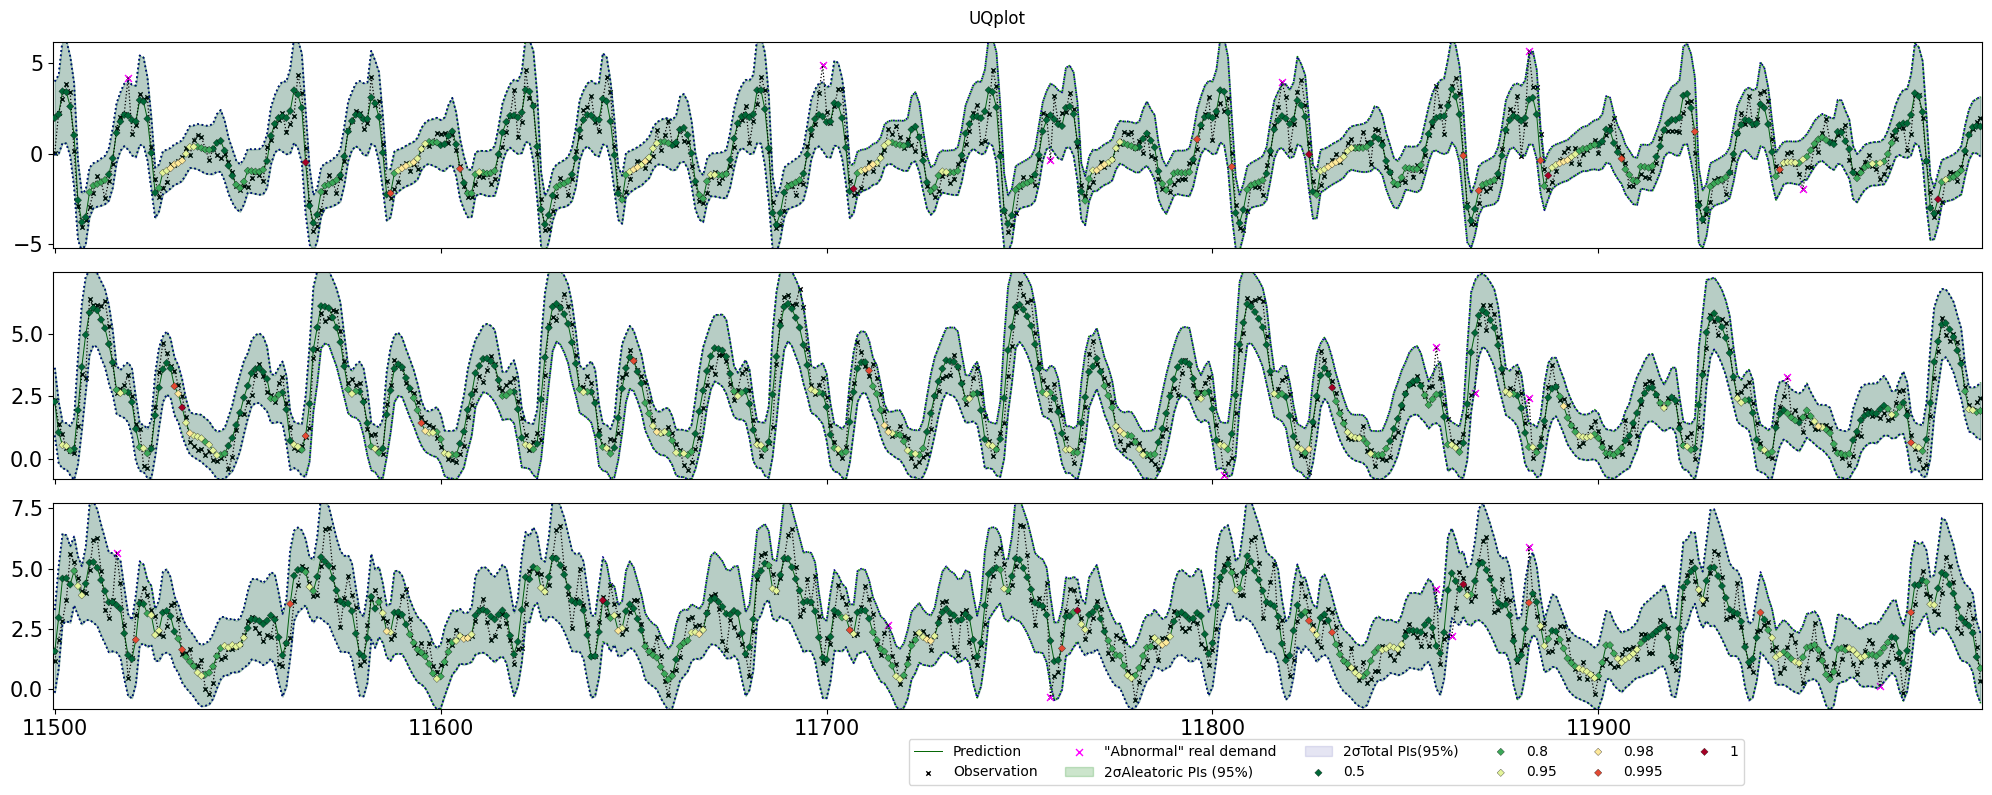

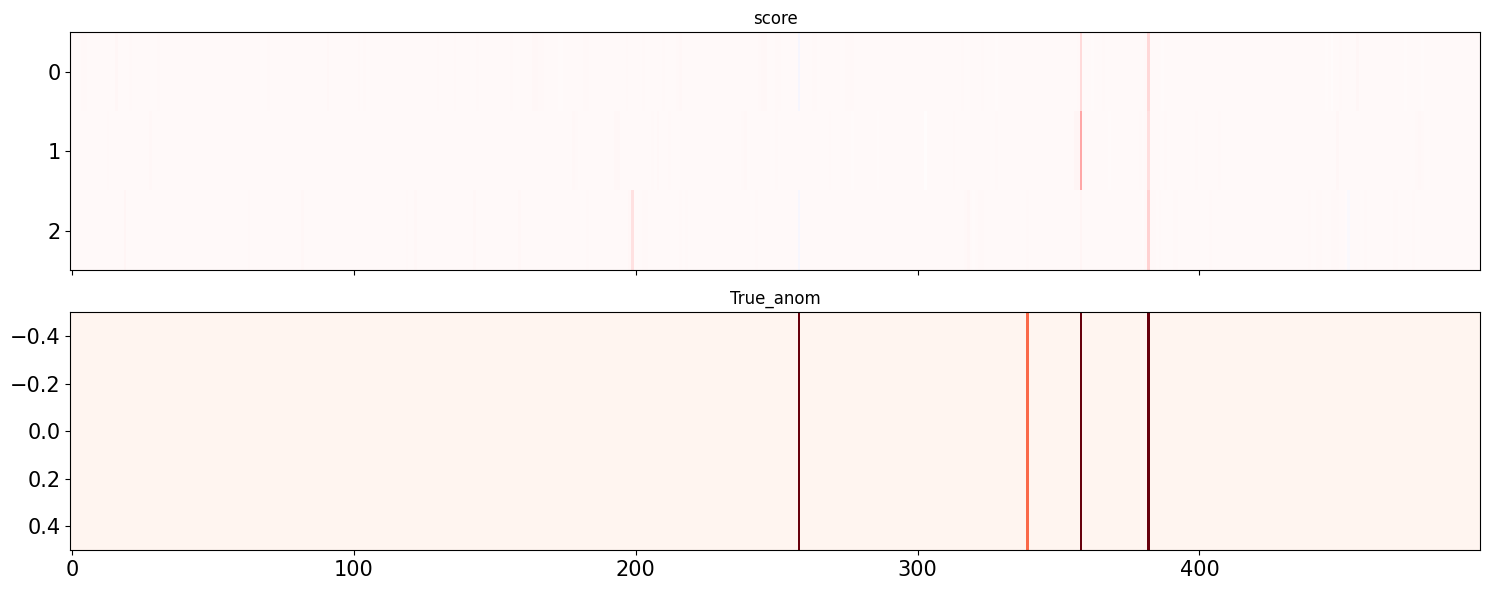

In [26]:
random_seed = 0

from uqmodels.custom_UQModel import UQModel, UQModel_KPI
from uqmodels.modelization.DL_estimator.lstm_ed import Lstm_ED_UQ
from uqmodels.modelization.DL_estimator.lstm_ed import (
    get_params_dict as get_params_dict_lstm,
)
from uqmodels.modelization.DL_estimator.lstm_ed import (
    get_training_parameters,
    get_UQEstimator_parameters,
)

values_true = {
    "LSTM_ED": {
        "target": [0.025, 0.16, 0.84, 0.975],
        "empirique": [
            0.012277777777777778,
            0.12983333333333333,
            0.9458888888888889,
            0.9935833333333334,
        ],
        "target_elvl": [0.5, 0.8, 0.95, 0.98, 0.995, 1],
        "empirique_elvl": [0.0, 2.0, 3.0, 4.0, 5.0, 6.0],
    }
}

name = "LSTM_ED_MC_Dropout"
type_output = "MC_Dropout"
model_params = get_params_dict_lstm(
    dim_ctx=X.shape[-1],
    dim_dyn=y.shape[-1],
    dim_target=y.shape[-1],
    size_window=20,
    n_windows=5,
    dim_horizon=5,
    dim_chan=1,
    type_output="MC_Dropout",
)
training_param = get_training_parameters(
    epochs=[5],
    b_s=[128],
    l_r=[0.0005],
    list_loss=["MSE", "BNN"],
    metrics=["MSE", "BNN"],
    param_loss=[2, 0.9],
)
UQEstimator_parameters = get_UQEstimator_parameters(
    model_parameters=model_params,
    training_parameters=training_param,
    type_output=type_output,
    factory_parameters={"factory_lag_st": 0, "factory_lag_lt": 0},
    rescale=False,
)

UQEstimator_initializer = Lstm_ED_UQ
UQEstimator_parameters = UQEstimator_parameters

DEEP_UQModel = UQModel_KPI(
    UQEstimator_initializer,
    UQEstimator_parameters,
    name=name,
    predictor=None,
    beta=0.001,
    reduc_filter_KPI=[1, 1, 1, 1, 1],
    reduc_filter_pred=[1, 0, 0, 0, 0],
    random_state=random_seed,
)

DEEP_UQModel._init_UQEstimator((X[train], y[train]), y[train])

# Afactory function turn sequence in Window with mutli-horizon prediction
# Manipulate sequence and apply factory on each batch : Less space memory / more time consuming
if True:  # For test purpose run both mode
    DEEP_UQModel.UQEstimator.training_parameters["generator"] = True
    DEEP_UQModel.fit([X[train], y[train]], y[train], verbose=1)
    pred, (UQ, PIs, Elvl) = DEEP_UQModel.predict((X, y))
    (pred, UQ), KPI_anom, PIs, Elvl = DEEP_UQModel.score((X, y), y)

# Apply factory on all sub-sequences, then learning on batch representation : lot of space memory / less time consuming
if True:
    DEEP_UQModel.UQEstimator.training_parameters["generator"] = False
    DEEP_UQModel._init_UQEstimator((X[train], y[train]), y[train])
    DEEP_UQModel.fit([X[train], y[train]], y[train], verbose=1)
    if True:  # Test save load procedure
        DEEP_UQModel.save("tests/model")
        del DEEP_UQModel
        DEEP_UQModel = UQModel()
        DEEP_UQModel.load("tests/model/" + name)
    pred, (UQ, PIs, Elvl) = DEEP_UQModel.predict((X, y))
    (pred, UQ), KPI_anom, PIs, Elvl = DEEP_UQModel.score((X, y), y)
# Inference procedure that provide prediction plus the specified UQKPIs
standards_evaluation_check_procedure(
    DEEP_UQModel,
    pred,
    UQ,
    PIs,
    Elvl,
    KPI_anom,
    values_true,
    name_in_dict="LSTM_ED",
    val_sensibility=1.5,
)
del DEEP_UQModel
delete_folder("tests/model/" + name)

start_fit
Epoch 1/5


E0000 00:00:1764754668.522871   32631 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/model_1/mouving_conv__embedding_9_1/dropout_111_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step - bnn_loss: 0.7736 - loss: 2.0652 - mse_loss: 1.4170 - val_bnn_loss: 0.8496 - val_loss: 1.1315 - val_mse_loss: 1.1654 - learning_rate: 5.0000e-04
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - bnn_loss: 0.8533 - loss: 1.1688 - mse_loss: 1.1695 - val_bnn_loss: 0.8884 - val_loss: 0.8754 - val_mse_loss: 1.0424 - learning_rate: 5.0000e-04
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - bnn_loss: 0.8715 - loss: 0.9987 - mse_loss: 1.0793 - val_bnn_loss: 0.9060 - val_loss: 0.7365 - val_mse_loss: 0.9307 - learning_rate: 5.0000e-04
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - bnn_loss: 0.8932 - loss: 0.8312 - mse_loss: 0.9388 - val_bnn_loss: 0.9424 - val_loss: 0.5776 - val_mse_loss: 0.7303 - learning_rate: 5.0000e-04
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - bnn_loss: 0.9104 - loss: 0.7253 - mse_loss: 0.8365 - val_bnn_loss: 0.9558 - val_loss: 0.5041 - val_mse_loss: 0.7123 - learning_rate: 5.0000e-04
Epoch 1/5


E0000 00:00:1764754736.696713   32631 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/model_1/mouving_conv__embedding_9_1/dropout_111_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 155ms/step - bnn_loss: 0.9635 - loss: 0.6563 - mse_loss: 0.8058 - val_bnn_loss: 0.9895 - val_loss: 0.2326 - val_mse_loss: 0.6736 - learning_rate: 5.0000e-04
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - bnn_loss: 0.9677 - loss: 0.4770 - mse_loss: 0.7745 - val_bnn_loss: 0.9870 - val_loss: 0.1615 - val_mse_loss: 0.6501 - learning_rate: 5.0000e-04
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - bnn_loss: 0.9666 - loss: 0.4013 - mse_loss: 0.7438 - val_bnn_loss: 0.9814 - val_loss: 0.1487 - val_mse_loss: 0.6488 - learning_rate: 5.0000e-04
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - bnn_loss: 0.9663 - loss: 0.3321 - mse_loss: 0.7086 - val_bnn_loss: 0.9894 - val_loss: 0.0041 - val_mse_loss: 0.5735 - learning_rate: 5.0000e-04
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - bnn_loss: 0.9671 - loss: 0.2588 - mse_loss: 0.6779 - val_bnn_loss: 0.9837 - val_loss: -0.0532 - val_mse_loss: 0.5276 - learning_rate: 5.0000e-04
250/250 ━━━━━━━━━━━━━━━━━━

...

57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 157ms/step - bnn_loss: 0.9685 - loss: 0.5023 - mse_loss: 0.6503 - val_bnn_loss: 0.9909 - val_loss: 0.3374 - val_mse_loss: 0.5276 - learning_rate: 5.0000e-04
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - bnn_loss: 0.9799 - loss: 0.4568 - mse_loss: 0.6205 - val_bnn_loss: 0.9938 - val_loss: 0.3183 - val_mse_loss: 0.4996 - learning_rate: 5.0000e-04
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - bnn_loss: 0.9836 - loss: 0.4333 - mse_loss: 0.6064 - val_bnn_loss: 0.9936 - val_loss: 0.3236 - val_mse_loss: 0.5080 - learning_rate: 5.0000e-04
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - bnn_loss: 0.9846 - loss: 0.4216 - mse_loss: 0.5905 - val_bnn_loss: 0.9927 - val_loss: 0.3382 - val_mse_loss: 0.4912 - learning_rate: 5.0000e-04
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - bnn_loss: 0.9864 - loss: 0.4058 - mse_loss: 0.5769 - val_bnn_loss: 0.9952 - val_loss: 0.3123 - val_mse_loss: 0.4780 - learning_rate: 5.0000e-04
Epoch 1/5


2025-12-03 09:41:39.676304: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
E0000 00:00:1764754927.094093   32631 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/model_1/mouving_conv__embedding_9_1/dropout_111_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutO

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - bnn_loss: 0.9696 - loss: 0.1780 - mse_loss: 0.6095

2025-12-03 09:42:17.146828: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


57/57 ━━━━━━━━━━━━━━━━━━━━ 40s 149ms/step - bnn_loss: 0.9690 - loss: 0.0681 - mse_loss: 0.5873 - val_bnn_loss: 0.9855 - val_loss: -0.2867 - val_mse_loss: 0.4697 - learning_rate: 5.0000e-04
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - bnn_loss: 0.9662 - loss: -0.0411 - mse_loss: 0.5658 - val_bnn_loss: 0.9840 - val_loss: -0.3175 - val_mse_loss: 0.4617 - learning_rate: 5.0000e-04
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - bnn_loss: 0.9662 - loss: -0.0783 - mse_loss: 0.5532 - val_bnn_loss: 0.9864 - val_loss: -0.3495 - val_mse_loss: 0.4569 - learning_rate: 5.0000e-04
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - bnn_loss: 0.9654 - loss: -0.0936 - mse_loss: 0.5469 - val_bnn_loss: 0.9827 - val_loss: -0.3233 - val_mse_loss: 0.4681 - learning_rate: 5.0000e-04
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - bnn_loss: 0.9664 - loss: -0.1194 - mse_loss: 0.5407 - val_bnn_loss: 0.9845 - val_loss: -0.4039 - val_mse_loss: 0.4461 - learning_rate: 5.0000e-04
250/250 ━━━━━━━━━

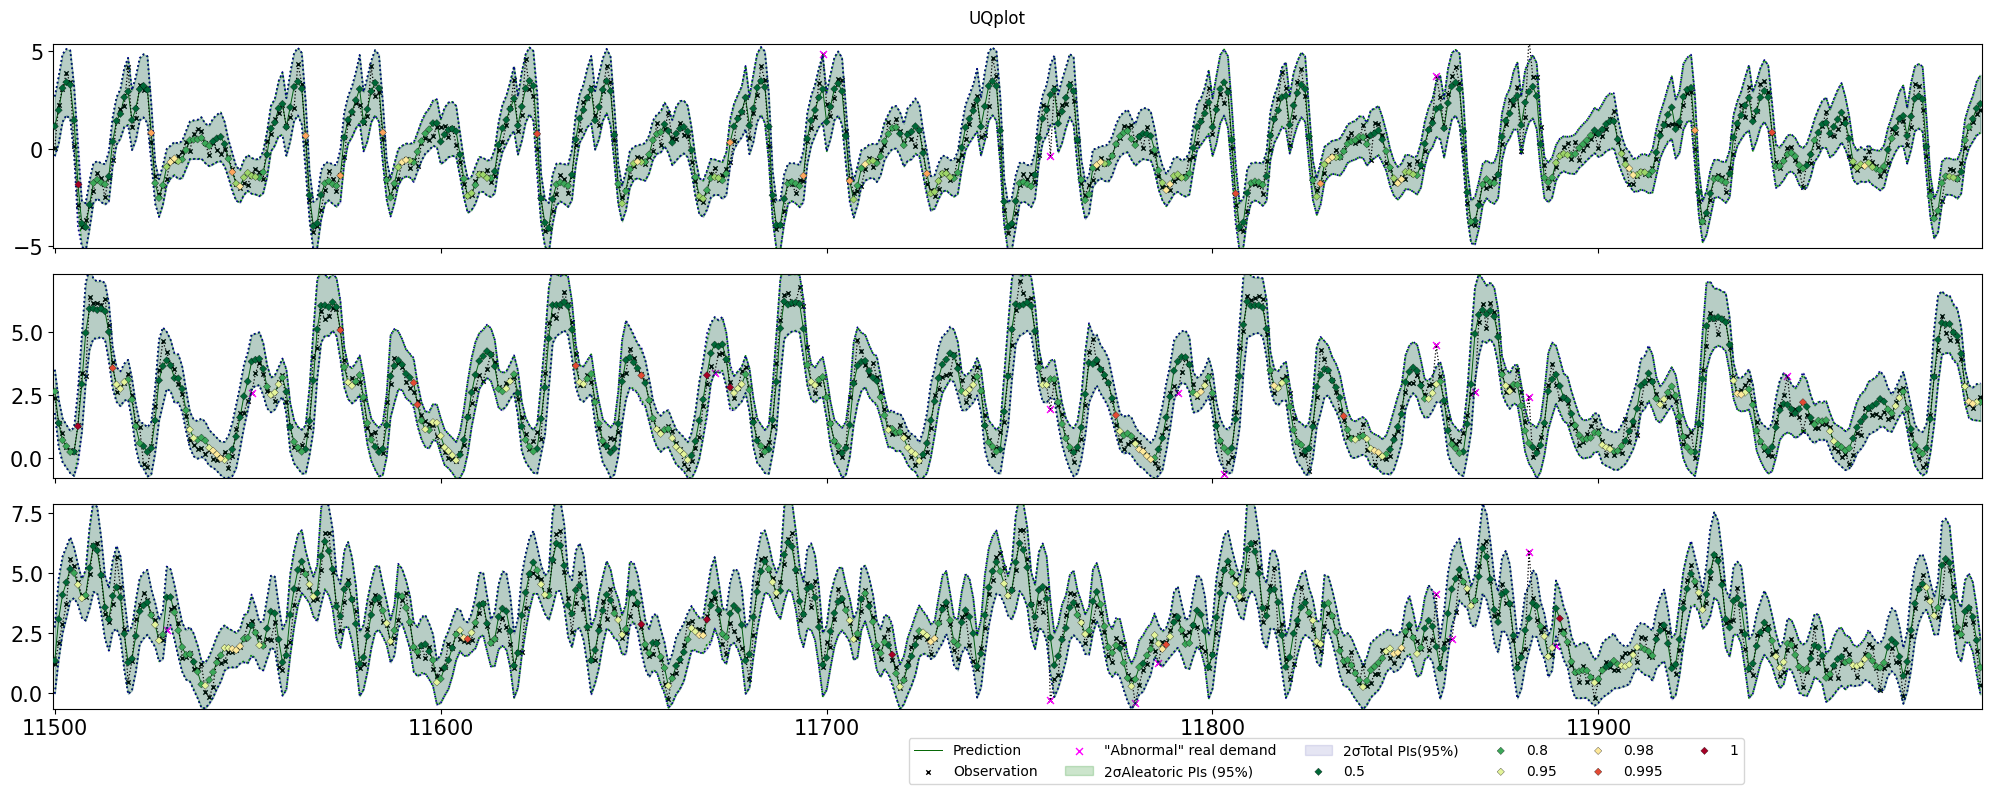

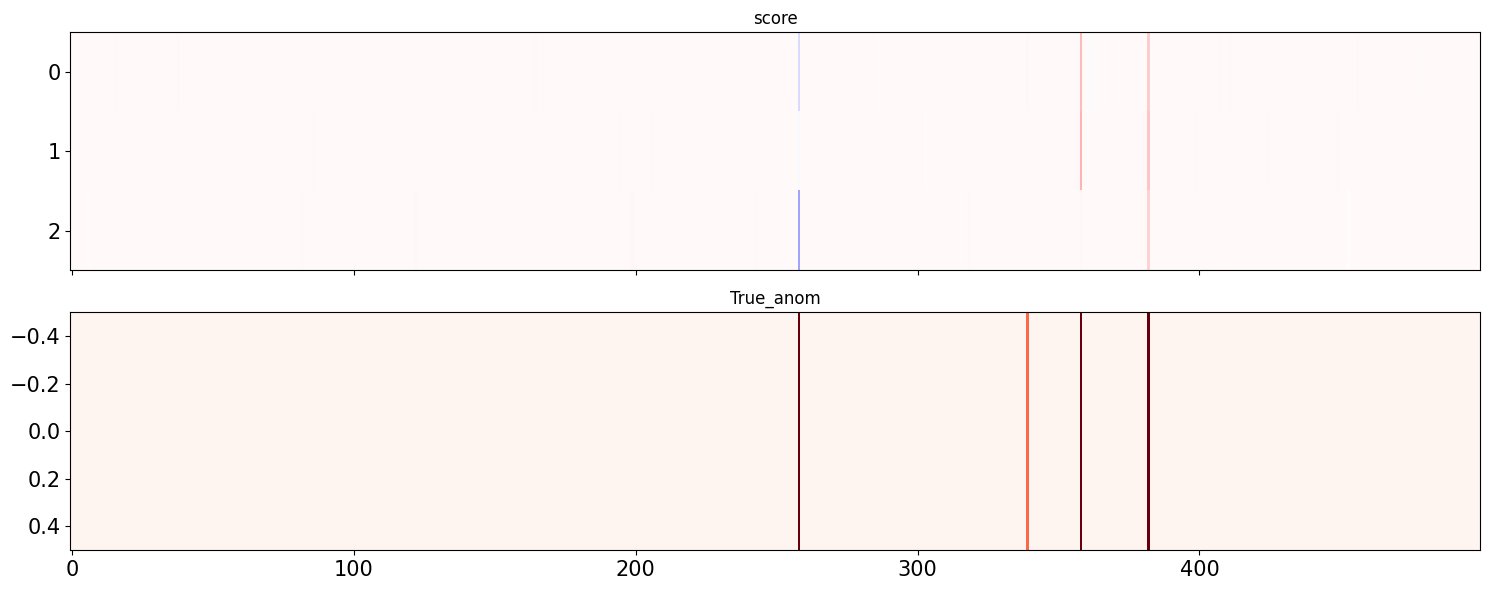

In [32]:

from uqmodels.custom_UQModel import UQModel, UQModel_KPI
from uqmodels.modelization.DL_estimator.transformer_ed import Transformer_ED_UQ
from uqmodels.modelization.DL_estimator.transformer_ed import (
    get_params_dict as get_params_dict_transformer,
)
from uqmodels.modelization.DL_estimator.transformer_ed import (
    get_training_parameters,
    get_UQEstimator_parameters,
)

# to actualise
values_true = {
    "Transformer_ED": {
        "target": [0.025, 0.16, 0.84, 0.975],
        "empirique": [
            0.012277777777777778,
            0.12983333333333333,
            0.9458888888888889,
            0.9935833333333334,
        ],
        "target_elvl": [0.5, 0.8, 0.95, 0.98, 0.995, 1],
        "empirique_elvl": [0.0, 2.0, 3.0, 4.0, 5.0, 6.0],
    }
}

type_output = "MC_Dropout"
name = "Transformer_ED_MC_Dropout"
model_params = get_params_dict_transformer(
    dim_ctx=X.shape[-1],
    dim_dyn=y.shape[-1],
    dim_target=y.shape[-1],
    size_window=40,
    n_windows=10,
    dim_horizon=5,
)
training_param = get_training_parameters(
    epochs=[5],
    b_s=[128],
    l_r=[0.0005],
    list_loss=["MSE", "BNN"],
    metrics=["MSE", "BNN"],
    param_loss=[2, 0.9],
)
UQEstimator_initializer = Transformer_ED_UQ
UQEstimator_parameters = get_UQEstimator_parameters(
    model_parameters=model_params,
    training_parameters=training_param,
    type_output=type_output,
    factory_parameters={"factory_lag_st": 0, "factory_lag_lt": 0},
    rescale=False,
)

# We can also create a more complexe UQmodel that handle several UQKPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator
UQEstimator_initializer = UQEstimator_initializer
UQEstimator_parameters = UQEstimator_parameters

# Instanciation of the UQmodel modeling pipeline
DEEP_UQModel = UQModel_KPI(
    UQEstimator_initializer,
    UQEstimator_parameters,
    name=name,
    predictor=None,
    beta=0.001,
    reduc_filter_KPI=[1, 1, 1, 1, 1],
    reduc_filter_pred=[1, 0, 0, 0, 0],
    random_state=random_seed,
)

# Fit procedure

# Apply factory at begin on all sub-sequences, then learning using folded representation : lot of space memory / less time consuming
DEEP_UQModel._init_UQEstimator((X[train], y[train]), y[train])

# Afactory function turn sequence in Window with mutli-horizon prediction
# Manipulate sequence and apply factory on each batch : Less space memory / more time consuming
if True:  # For test purpose run both mode
    DEEP_UQModel.UQEstimator.training_parameters["generator"] = True
    DEEP_UQModel.fit([X[train], y[train]], y[train], verbose=1)
    pred, (UQ, PIs, Elvl) = DEEP_UQModel.predict((X, y))
    (pred, UQ), KPI_anom, PIs, Elvl = DEEP_UQModel.score((X, y), y)

# Apply factory on all sub-sequences, then learning on batch representation : lot of space memory / less time consuming
if True:
    DEEP_UQModel.UQEstimator.training_parameters["generator"] = False
    DEEP_UQModel.fit([X[train], y[train]], y[train], verbose=1)
    if (
        False
    ):  # Test save load procedure : issues laading procedure run but doesn't load an operational model
        DEEP_UQModel.save("tests/model")
        DEEP_UQModel = UQModel()
        DEEP_UQModel.load("tests/model/" + name)
pred, (UQ, PIs, Elvl) = DEEP_UQModel.predict((X, y))
(pred, UQ), KPI_anom, PIs, Elvl = DEEP_UQModel.score((X, y), y)

standards_evaluation_check_procedure(
    DEEP_UQModel,
    pred,
    UQ,
    PIs,
    Elvl,
    KPI_anom,
    values_true,
    name_in_dict="Transformer_ED",
    val_sensibility=1.5,
)
del DEEP_UQModel
# delete_folder('tests/model/'+name)